**K-means**

In [ ]:
# objective - the objective of this class is to apply k-means clustering on logistic dataset in order to group delivery locations into
# optimal clusters based on geographical and operattional features to examine the most sutble no of clusters sing evaluation techniques
#such ad elbow method.

In [ ]:
import numpy as np
import pandas as Pd

In [ ]:
df=pd.read_csv("logistics_2000_dataset.csv")

In [ ]:
df.head()

,latitude,longitude,distance_km,demand,accessibility
0,26.804834,80.864214,9.883383,42,0.091883
1,27.012257,80.858912,20.175776,21,0.047224
2,26.933518,81.096252,17.222248,37,0.054878
3,26.885517,80.859837,9.776628,27,0.092793
4,26.726167,80.867902,16.000369,29,0.058822


In [ ]:
# Select features
x=df[['latitude','longitude']]

In [ ]:
# Standardrization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

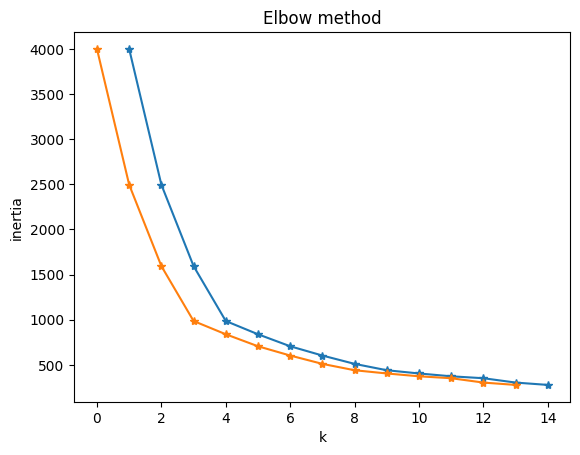

In [ ]:
# Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]
K_range=range(1,15)
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(K_range,inertia,inertia,marker='*')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('Elbow method')
plt.show()

In [ ]:
# Final model
kmeans = KMeans(n_clusters=8, random_state=42)
df['cluster']=kmeans.fit_predict(x_scaled)
centers=kmeans.cluster_centers_

In [ ]:
centers_original=scaler.inverse_transform(centers)

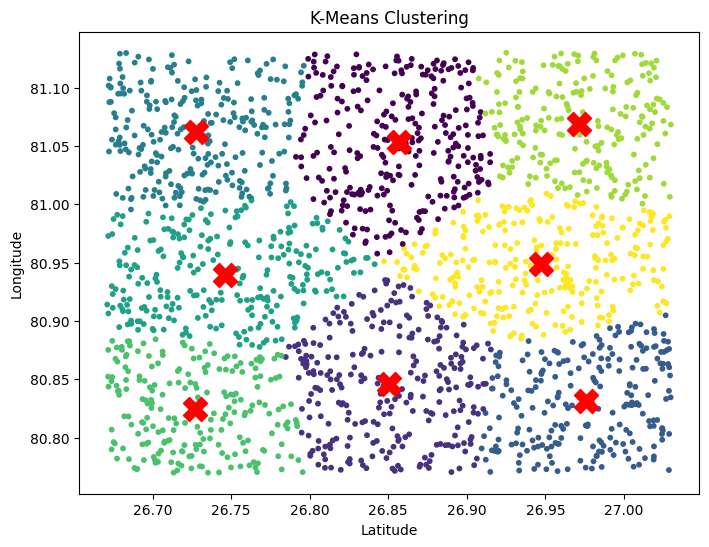

In [ ]:
plt.figure(figsize=(8,6))

# Plot cluster points
plt.scatter(
    df['latitude'],
    df['longitude'],
    c=df['cluster'],
    s=10
)

# Plot centroids (FIXED)
plt.scatter(
    centers_original[:,0],
    centers_original[:,1],
    s=300,
    marker="X",
    c="red"
)

plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('K-Means Clustering')
plt.show()


In [ ]:
# cluster summary
summary=df.groupby('cluster').agg({
    'distance_km':'mean',
    'demand':'mean',
    'accessibility':'mean'
})
print(summary)

         distance_km     demand  accessibility
cluster                                       
0          10.923506  25.971326       0.102815
1          11.095258  25.548148       0.100058
2          18.768881  24.883117       0.052124
3          17.943442  24.968504       0.054919
4          12.048563  24.403042       0.094829
5          18.902627  24.706977       0.051835
6          18.315784  25.059908       0.053568
7          11.288263  24.664207       0.107770
